# YOLOv26n Optimization Pipeline (ESP32-P4)

**Note:** This notebook contains optimizations specific to the ESP32-P4 target,
including PIE SIMD-native HardSiLU8 activations that are not portable to other
ESP32 variants (S3, etc.).

This notebook demonstrates the complete optimization pipeline for deploying
YOLOv26n on ESP-DL. It covers Post-Training Quantization (PTQ), optional
Trained Quantization Thresholds (TQT) for accuracy recovery, and direct
LUT Fusion for hardware-accelerated INT16 activations.

The Neural Morphing integration (SiLU → HardSiLU8) is applied by loading
a pre-morphed `.native` graph that replaces eligible SiLU activations with
PIE-native HardSiLU8 operations for the ESP32-P4 SIMD engine.


In [1]:
# ==========================================
# CELL 1: Standard Imports & Paths
# ==========================================
import os
import sys

sys.path.append('scripts')

import torch
import types
from esp_ppq.api import get_target_platform
import esp_ppq.lib as PFL
from esp_ppq.executor import TorchExecutor
from esp_ppq.core import QuantizationVisibility, TargetPlatform
from esp_ppq.api.interface import load_onnx_graph, load_native_graph
from esp_ppq.quantization.optim import (
    QuantizeSimplifyPass, QuantizeFusionPass, ParameterQuantizePass,
    RuntimeCalibrationPass, PassiveParameterQuantizePass, QuantAlignmentPass,
    TrainedQuantizationThresholdPass
)


    ___________ ____        ____  ____  ____
   / ____/ ___// __ \      / __ \/ __ \/ __ \
  / __/  \__ \/ /_/ /_____/ /_/ / /_/ / / / /
 / /___ ___/ / ____/_____/ ____/ ____/ /_/ /
/_____//____/_/         /_/   /_/    \___\_\




In [2]:
# ==========================================
# CELL 2: User Configuration
# ==========================================
IMG_SZ_I = 512
PLATFORM = "p4"  # Fixed — see below
DATA_YAML_FILE_I = "coco.yaml"
INT16_LUT_STEP_I = 32

# This notebook relies on multiple ESP32-P4-only optimizations:
#   - HardSiLU8 PIE SIMD activation kernel
#   - TransposePIE SIMD layout permutation
#   - TiledConv L2-cache blocking (P4 has L2, S3 does not)
#   - Nearest-neighbor LUT using P4-specific SIMD instructions
assert PLATFORM == "p4", (
    "This notebook uses ESP32-P4-only optimizations (HardSiLU8 PIE, "
    "TransposePIE, TiledConv L2-cache, nearest-neighbor LUT SIMD). "
    "Other targets are not supported."
)


In [3]:
# ==========================================
# CELL 3: Configuration Injection
# ==========================================
class QATConfig:
    IMG_SZ = IMG_SZ_I
    DEVICE = "cuda" if torch.cuda.is_available() and torch.cuda.device_count() > 0 else "cpu"
    DATA_YAML_FILE = DATA_YAML_FILE_I
    BATCH_SIZE = 24
    CALIB_MAX_IMAGES = 2560
    CALIB_VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    DATA_FALLBACK_PATH = "coco2017/images/train2017"
    CALIB_STEPS = 64
    QUANT_CALIB_METHOD = "percentile"
    QUANT_ALIGNMENT = "Align to Output"
    TARGET_PLATFORM = get_target_platform("esp32" + PLATFORM, 8)

    # LUT Hyperparameters
    INT16_LUT_STEP = INT16_LUT_STEP_I

    # TQT Hyperparameters
    TQT_STEPS = 200
    TQT_LR = 2e-5
    TQT_INT_LAMBDA = 0.25
    TQT_BLOCK_SIZE = 1
    TQT_COLLECTING_DEVICE = "cpu"

    BASE_DIR = os.getcwd()
    MODEL_NAME = "yolo26n"
    PT_FILE = f"{MODEL_NAME}.pt"
    ONNX_FILE = f"{MODEL_NAME}_export.onnx"
    ESPDL_OUTPUT_DIR = os.path.join(BASE_DIR, "output", f"{DATA_YAML_FILE_I[:-5]}_{IMG_SZ_I}_s8_{PLATFORM}")
    ONNX_PATH = os.path.join(ESPDL_OUTPUT_DIR, ONNX_FILE)

if 'config' not in sys.modules:
    sys.modules['config'] = types.ModuleType('config')
sys.modules['config'].QATConfig = QATConfig

In [4]:
# ==========================================
# CELL 4: Local Modules & Environment Setup
# ==========================================
from utils import seed_everything, register_mod_op, get_exclusive_ancestors
from dataset import get_calibration_loader
from ultralytics.data.utils import check_det_dataset
from esp_ppq_patch import apply_esp_ppq_patches
from esp_ppq_patch_2 import apply_addlut_patch
from notebook_helpers import extract_model_meta, prepare_onnx, prune_graph_safely

from esp_ppq_lut.passes import EspdlLUTFusionPass

os.makedirs(QATConfig.ESPDL_OUTPUT_DIR, exist_ok=True)

import esp_ppq_lut as esp_lut
esp_lut.initialize(step=QATConfig.INT16_LUT_STEP, verbose=True)

seed_everything(1234)
register_mod_op()
apply_esp_ppq_patches()
apply_addlut_patch()

print("Environment and Configuration setup complete.")

[ESP-PPQ-LUT] Activation forwarders registered for simulation.
[ESPDL Emulator] LUT Operation Handler Registered Globally (Nearest-Neighbor).
[ESPDL Exporter] Registered HardwareAwareExporter for: ESPDL_INT8
[ESPDL Exporter] Registered HardwareAwareExporter for: ESPDL_INT16
[ESPDL Exporter] Registered HardwareAwareExporter for: ESPDL_S3_INT8
[ESPDL Exporter] Registered HardwareAwareExporter for: ESPDL_S3_INT16
[ESP-PPQ-LUT] Activation forwarders registered for simulation.
[ESP-PPQ-LUT] Extension Initialized (Default Step=32)
Registered 'Mod' handler for PPQ.
Applying ESP-PPQ Runtime Patches...
  [x] Patched OnnxParser.refine_graph
  [x] Patched Backend: Slice
  [x] Patched Backend: Gather
ESP-PPQ Runtime Patches Applied Successfully.
Applying fix to AddLUTPattern.export for correct LUT step propagation...
Environment and Configuration setup complete.


In [5]:
# ==========================================
# CELL 5: ONNX Export & Metadata Extraction
# ==========================================
prepare_onnx()
model_meta = extract_model_meta()

Applying ESP-DL patches for export...
Patched 2 Attention modules.
Patched Detect module: <class 'ultralytics.nn.modules.head.Detect'>
Ultralytics 8.4.7  Python-3.9.21 torch-2.8.0+cu126 CPU (13th Gen Intel Core(TM) i7-13650HX)
>> Fuse method blocked! Keeping all heads.
YOLO26n summary (fused): 146 layers, 2,562,496 parameters, 0 gradients, 6.0 GFLOPs

PyTorch: starting from 'yolo26n.pt' with input shape (16, 3, 512, 512) BCHW and output shape(s) ((16, 84, 64, 64), (16, 84, 32, 32), (16, 84, 16, 16), (16, 84, 64, 64), (16, 84, 32, 32), (16, 84, 16, 16)) (5.3 MB)

ONNX: starting export with onnx 1.17.0 opset 13...
ONNX: simplifying with onnxsim 0.4.36...
ONNX: export success  1.6s, saved as 'c:\Users\orani\bilel\git_projects\TQT\low-level_optimizations\esp-dl\examples\tutorial\how_to_quantize_model\quantize_yolo26\output\coco_512_s8_p4\yolo26n_export.onnx' (9.9 MB)

Export complete (2.6s)
Results saved to C:\Users\orani\bilel\git_projects\TQT\low-level_optimizations\esp-dl\examples\tutor

In [6]:
# ==========================================
# CELL 6: Custom Ops Registration (HardSiLU8)
# ==========================================
# Register the HardSiluPie8 operation handler so that
# ESP-PPQ can quantize and emulate the PIE-native activation.
import custom_ops_patch

[custom_ops_patch] Applied: TransposePIE
[custom_ops_patch] Enabled transpose debug table
[custom_ops_patch] Enabled TransposePIE auto-rename (int8_only=True)
[custom_ops_patch] Applied: TiledConvBlock fusion
[custom_ops_patch] Enabled TiledConvBlock fusion
[custom_ops_patch] Applied: HardSiluPie8


In [7]:
# ==========================================
# CELL 7: Graph Loading & Branch Separation
# ==========================================
print("Loading ONNX Graph...")
graph = load_onnx_graph(onnx_import_file=QATConfig.ONNX_PATH)

# Override with morphed HardSiLU8 graph (Neural Morphing T1)
MORPHED_NATIVE = os.path.join(QATConfig.BASE_DIR, "neural_morphing", "integrations", "yolo26n", "Transformation1_SiLU_to_HardSiLU", "output", "T1_silu_hsilu_512_p4", "morphed_hsilu.native")
graph = load_native_graph(MORPHED_NATIVE)
n_hsilu = sum(1 for op in graph.operations.values() if op.type == 'HardSiluPie8')
print(f"Morphed graph loaded: {n_hsilu} HardSiluPie8 activations")

# Separate Aux (training) / Main (inference) branches
output_names = list(graph.outputs.keys())
aux_ops, main_ops = set(), set()
if len(output_names) >= 6:
    aux_outputs  = output_names[0:3]
    main_outputs = output_names[3:6]
    aux_ops  = get_exclusive_ancestors(graph, aux_outputs, main_outputs)
    main_ops = get_exclusive_ancestors(graph, main_outputs, aux_outputs)

# Configure quantizer and dispatcher
quantizer = PFL.Quantizer(platform=QATConfig.TARGET_PLATFORM, graph=graph)
dispatching_table = PFL.Dispatcher(graph=graph, method="conservative").dispatch(
    quantizer.quant_operation_types
)
for opname, platform in dispatching_table.items():
    if platform == TargetPlatform.UNSPECIFIED:
        dispatching_table[opname] = TargetPlatform(quantizer.target_platform)

# Force Aux Branch to FP32 (will be pruned in graph surgery)
for op in aux_ops:
    if op.name in dispatching_table:
        dispatching_table[op.name] = TargetPlatform.FP32

Loading ONNX Graph...
Morphed graph loaded: 45 HardSiluPie8 activations


In [8]:
# ==========================================
# CELL 8: Hardware Precision Targets (INT16 / FP32)
# ==========================================
# Force high-sensitivity Head and Neck exit layers to INT16
INT16_PLATFORM = get_target_platform("esp32" + PLATFORM, 16)

int16_layers = {
    # Neck Exits
    "/model.16/cv2/conv/Conv", "/model.16/cv2/conv/Conv/Swish",
    "/model.19/cv2/conv/Conv", "/model.19/cv2/conv/Conv/Swish",
    "/model.22/cv2/conv/Conv", "/model.22/cv2/conv/Conv/Swish",
    # One2One Box Head
    "/model.23/one2one_cv2.0/one2one_cv2.0.0/conv/Conv", "/model.23/one2one_cv2.0/one2one_cv2.0.0/conv/Conv/Swish",
    "/model.23/one2one_cv2.0/one2one_cv2.0.1/conv/Conv", "/model.23/one2one_cv2.0/one2one_cv2.0.1/conv/Conv/Swish",
    "/model.23/one2one_cv2.0/one2one_cv2.0.2/Conv",
    "/model.23/one2one_cv2.1/one2one_cv2.1.0/conv/Conv", "/model.23/one2one_cv2.1/one2one_cv2.1.0/conv/Conv/Swish",
    "/model.23/one2one_cv2.1/one2one_cv2.1.1/conv/Conv", "/model.23/one2one_cv2.1/one2one_cv2.1.1/conv/Conv/Swish",
    "/model.23/one2one_cv2.1/one2one_cv2.1.2/Conv",
    "/model.23/one2one_cv2.2/one2one_cv2.2.0/conv/Conv", "/model.23/one2one_cv2.2/one2one_cv2.2.0/conv/Conv/Swish",
    "/model.23/one2one_cv2.2/one2one_cv2.2.1/conv/Conv", "/model.23/one2one_cv2.2/one2one_cv2.2.1/conv/Conv/Swish",
    "/model.23/one2one_cv2.2/one2one_cv2.2.2/Conv",
    # One2One Class Head
    "/model.23/one2one_cv3.0/one2one_cv3.0.0/one2one_cv3.0.0.0/conv/Conv", "/model.23/one2one_cv3.0/one2one_cv3.0.0/one2one_cv3.0.0.0/conv/Conv/Swish",
    "/model.23/one2one_cv3.0/one2one_cv3.0.0/one2one_cv3.0.0.1/conv/Conv", "/model.23/one2one_cv3.0/one2one_cv3.0.0/one2one_cv3.0.0.1/conv/Conv/Swish",
    "/model.23/one2one_cv3.0/one2one_cv3.0.1/one2one_cv3.0.1.0/conv/Conv", "/model.23/one2one_cv3.0/one2one_cv3.0.1/one2one_cv3.0.1.0/conv/Conv/Swish",
    "/model.23/one2one_cv3.0/one2one_cv3.0.1/one2one_cv3.0.1.1/conv/Conv", "/model.23/one2one_cv3.0/one2one_cv3.0.1/one2one_cv3.0.1.1/conv/Conv/Swish",
    "/model.23/one2one_cv3.0/one2one_cv3.0.2/Conv",
    "/model.23/one2one_cv3.1/one2one_cv3.1.0/one2one_cv3.1.0.0/conv/Conv", "/model.23/one2one_cv3.1/one2one_cv3.1.0/one2one_cv3.1.0.0/conv/Conv/Swish",
    "/model.23/one2one_cv3.1/one2one_cv3.1.0/one2one_cv3.1.0.1/conv/Conv", "/model.23/one2one_cv3.1/one2one_cv3.1.0/one2one_cv3.1.0.1/conv/Conv/Swish",
    "/model.23/one2one_cv3.1/one2one_cv3.1.1/one2one_cv3.1.1.0/conv/Conv", "/model.23/one2one_cv3.1/one2one_cv3.1.1/one2one_cv3.1.1.0/conv/Conv/Swish",
    "/model.23/one2one_cv3.1/one2one_cv3.1.1/one2one_cv3.1.1.1/conv/Conv", "/model.23/one2one_cv3.1/one2one_cv3.1.1/one2one_cv3.1.1.1/conv/Conv/Swish",
    "/model.23/one2one_cv3.1/one2one_cv3.1.2/Conv",
    "/model.23/one2one_cv3.2/one2one_cv3.2.0/one2one_cv3.2.0.0/conv/Conv", "/model.23/one2one_cv3.2/one2one_cv3.2.0/one2one_cv3.2.0.0/conv/Conv/Swish",
    "/model.23/one2one_cv3.2/one2one_cv3.2.0/one2one_cv3.2.0.1/conv/Conv", "/model.23/one2one_cv3.2/one2one_cv3.2.0/one2one_cv3.2.0.1/conv/Conv/Swish",
    "/model.23/one2one_cv3.2/one2one_cv3.2.1/one2one_cv3.2.1.0/conv/Conv", "/model.23/one2one_cv3.2/one2one_cv3.2.1/one2one_cv3.2.1.0/conv/Conv/Swish",
    "/model.23/one2one_cv3.2/one2one_cv3.2.1/one2one_cv3.2.1.1/conv/Conv", "/model.23/one2one_cv3.2/one2one_cv3.2.1/one2one_cv3.2.1.1/conv/Conv/Swish",
    "/model.23/one2one_cv3.2/one2one_cv3.2.2/Conv"
}

for op in graph.operations.values():
    if op.name in dispatching_table and op.name in int16_layers:
        dispatching_table[op.name] = INT16_PLATFORM

# Force Concat nodes to FP32 (ESP-DL alignment workaround)
fp32_layers = {"/model.23/Concat_5", "/model.23/Concat_3", "/model.23/Concat_4"}
for op in main_ops:
    if op.name in fp32_layers:
        dispatching_table[op.name] = TargetPlatform.FP32

print("Applying dispatch types...")
for op in graph.operations.values():
    quantizer.quantize_operation(op_name=op.name, platform=dispatching_table[op.name])

Applying dispatch types...


In [9]:
# ==========================================
# CELL 9: Linear Optimization Pipeline (PTQ + TQT + LUT)
# ==========================================
print("Running Linear Optimization Pipeline (Calibration -> TQT -> LUT)...")
data_cfg = check_det_dataset(QATConfig.DATA_YAML_FILE)
cali_loader = get_calibration_loader(data_cfg)

executor = TorchExecutor(graph=graph)
dummy_input = torch.zeros([1, 3, QATConfig.IMG_SZ, QATConfig.IMG_SZ]).to(QATConfig.DEVICE)
executor.tracing_operation_meta(inputs=dummy_input)

pipeline = PFL.Pipeline([
    QuantizeSimplifyPass(),
    QuantizeFusionPass(activation_type=quantizer.activation_fusion_types),
    ParameterQuantizePass(),
    RuntimeCalibrationPass(method=QATConfig.QUANT_CALIB_METHOD),

    # Accuracy Recovery 
    TrainedQuantizationThresholdPass(
        steps=QATConfig.TQT_STEPS,
        lr=QATConfig.TQT_LR,
        int_lambda=QATConfig.TQT_INT_LAMBDA,
        block_size=QATConfig.TQT_BLOCK_SIZE,
        collecting_device=QATConfig.TQT_COLLECTING_DEVICE
    ),

    PassiveParameterQuantizePass(clip_visiblity=QuantizationVisibility.EXPORT_WHEN_ACTIVE),
    QuantAlignmentPass(elementwise_alignment=QATConfig.QUANT_ALIGNMENT),

    # Direct LUT Conversion for HW INT16 Swish emulation
    EspdlLUTFusionPass(
        target_ops=['Swish'],
        lut_step=QATConfig.INT16_LUT_STEP
    ),
])

from custom_ops_patch import enable_hardsilu_training_mode, disable_hardsilu_training_mode
enable_hardsilu_training_mode()  

pipeline.optimize(
    calib_steps=QATConfig.CALIB_STEPS,
    collate_fn=(lambda x: x.type(torch.float).to(QATConfig.DEVICE)),
    graph=graph,
    dataloader=cali_loader,
    executor=executor,
)

disable_hardsilu_training_mode() 

print("Pipeline complete.")

Running Linear Optimization Pipeline (Calibration -> TQT -> LUT)...
Using dataset at: C:\Users\orani\OneDrive\Desktop\bilel\Projects\p_2025\esp32p4dl_pip\pytorch_lab\version1\yolov5\datasets\coco\images\train2017
[WARNING][PPQ][2026-06-08 04:45:09]:  Unexpected input value of operation /model.11/Resize, recieving "None" at its input 1
[WARNING][PPQ][2026-06-08 04:45:09]:  Unexpected input value of operation /model.14/Resize, recieving "None" at its input 1
[custom_ops_patch] HardSiluPie8 training mode: ON
[04:45:09] PPQ Quantize Simplify Pass Running ...         Finished.
[04:45:09] PPQ Quantization Fusion Pass Running ...       Finished.
[04:45:09] PPQ Parameter Quantization Pass Running ...    Finished.
[04:45:09] PPQ Runtime Calibration Pass Running ...       

Calibration Progress(Phase 1): 100%|██████████| 64/64 [06:31<00:00,  6.12s/it]


Finished.
[04:51:41] ESP-PPQ TQT Optimization Running ...           
Check following parameters:
Is Scale Trainable:        True
Interested Layers:         []
Num of blocks:             106
Learning Rate:             2e-05
Steps:                     200
Gamma:                     0.0
int_lambda:                0.25

# Block [1 / 106]: [/model.0/conv/Conv -> /model.0/conv/Conv/Swish_HardSiluPie8]


# Tuning Procedure : 100%|██████████| 200/200 [00:19<00:00, 10.07it/s]


# Tuning Finished  : (0.0599 -> 0.0454) [Block Loss]

# Block [2 / 106]: [/model.1/conv/Conv -> /model.1/conv/Conv/Swish_HardSiluPie8]


...

# Tuning Finished  : (0.0728 -> 0.0727) [Block Loss]

# Block [105 / 106]: [/model.23/one2one_cv3.2/one2one_cv3.2.1/one2one_cv3.2.1.1/conv/Conv -> /model.23/one2one_cv3.2/one2one_cv3.2.1/one2one_cv3.2.1.1/conv/Conv/Swish]


# Tuning Procedure : 100%|██████████| 200/200 [00:00<00:00, 231.20it/s]


# Tuning Finished  : (0.3369 -> 0.3352) [Block Loss]

# Block [106 / 106]: [/model.23/one2one_cv3.2/one2one_cv3.2.2/Conv -> /model.23/one2one_cv3.2/one2one_cv3.2.2/Conv]


# Tuning Procedure : 100%|██████████| 200/200 [00:00<00:00, 261.72it/s]


# Tuning Finished  : (4.8483 -> 4.8104) [Block Loss]

Finished.
[05:48:48] PPQ Passive Parameter Quantization Running ... Finished.
[05:48:48] PPQ Quantization Alignment Pass Running ...    Finished.
[05:48:48] ESPDL LUT Fusion Pass Running ...              Finished.
[custom_ops_patch] HardSiluPie8 training mode: OFF
Pipeline complete.


In [10]:
# ==========================================
# CELL 10: Validation (Optional - Check Quantized Graph mAP)
# ==========================================

from trainer import QATTrainer
print("Evaluating Target ESP-DL Emulated mAP...")
dummy_trainer = QATTrainer(graph=graph, model_meta=model_meta, device=QATConfig.DEVICE)
val_mAP = dummy_trainer.eval()
print(f"Final Quantized mAP50-95: {val_mAP:.3f}")


Evaluating Target ESP-DL Emulated mAP...
Ultralytics 8.4.7  Python-3.9.21 torch-2.8.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 264.4129.1 MB/s, size: 148.8 KB)
val: Scanning C:\Users\orani\OneDrive\Desktop\bilel\Projects\p_2025\esp32p4dl_pip\pytorch_lab\version1\yolov5\datasets\coco\labels\val2017.cache... 4952 images, 48 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5000/5000  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 209/209 2.0it/s 1:46<0.6ss

                   all       5000      36335      0.655      0.452      0.507      0.362
Final Quantized mAP50-95: 0.362


In [11]:
# ==========================================
# CELL 11: Graph Surgery (Pruning and Output Tearing)
# ==========================================
# Prune auxiliary training head and split Concat outputs into
# discrete box/cls tensors matching the ESP-DL C++ runtime layout.
print("Slicing output Concat nodes into 6 discrete tensors...")

# 1. Remove Aux Heads
output_names = list(graph.outputs.keys())
if len(output_names) >= 6:
    for name in output_names[0:3]:
        if name in graph.outputs: graph.outputs.pop(name)
    prune_graph_safely(graph)

# 2. Slice Concat -> Box/Cls
targets = ["one2one_p3", "one2one_p4", "one2one_p5"]
collected_outputs = {}
for target_name in targets:
    if target_name in graph.outputs:
        original_output_var = graph.variables[target_name]
        producer = original_output_var.source_op
        if producer and producer.type == "Concat":
            box_var, cls_var = None, None
            for input_var in producer.inputs:
                dims = input_var.shape
                if dims is not None:
                    if 4 in dims: box_var = input_var
                    elif model_meta['nc'] in dims: cls_var = input_var
            if box_var and cls_var:
                pair_config = [
                    (box_var, f"{target_name}_box"),
                    (cls_var, f"{target_name}_cls"),
                ]
                for var, new_name in pair_config:
                    old_name = var.name
                    if old_name in graph.variables: graph.variables.pop(old_name)
                    var._name = new_name
                    graph.variables[new_name] = var
                    collected_outputs[new_name] = var
                graph.outputs.pop(target_name)
                graph.remove_operation(producer, keep_coherence=False)
                for var in producer.inputs:
                    if producer in var.dest_ops: var.dest_ops.remove(producer)

# 3. Enforce output order matching ESP-DL C++ expectations
final_output_list = [
    "one2one_p3_box", "one2one_p3_cls",
    "one2one_p4_box", "one2one_p4_cls",
    "one2one_p5_box", "one2one_p5_cls"
]
graph.outputs.clear()
for name in final_output_list:
    if name in collected_outputs:
        graph.outputs[name] = collected_outputs[name]

prune_graph_safely(graph)
print(f"Graph outputs: {list(graph.outputs.keys())}")

Slicing output Concat nodes into 6 discrete tensors...
Graph outputs: ['one2one_p3_box', 'one2one_p3_cls', 'one2one_p4_box', 'one2one_p4_cls', 'one2one_p5_box', 'one2one_p5_cls']


[eval_espdl_model] Dataset: coco.yaml | Classes: 80
[eval_espdl_model] 5 detection(s) → saved: c:\Users\orani\bilel\git_projects\TQT\low-level_optimizations\esp-dl\examples\tutorial\how_to_quantize_model\quantize_yolo26\results\bus_s_512_s8_p4.png


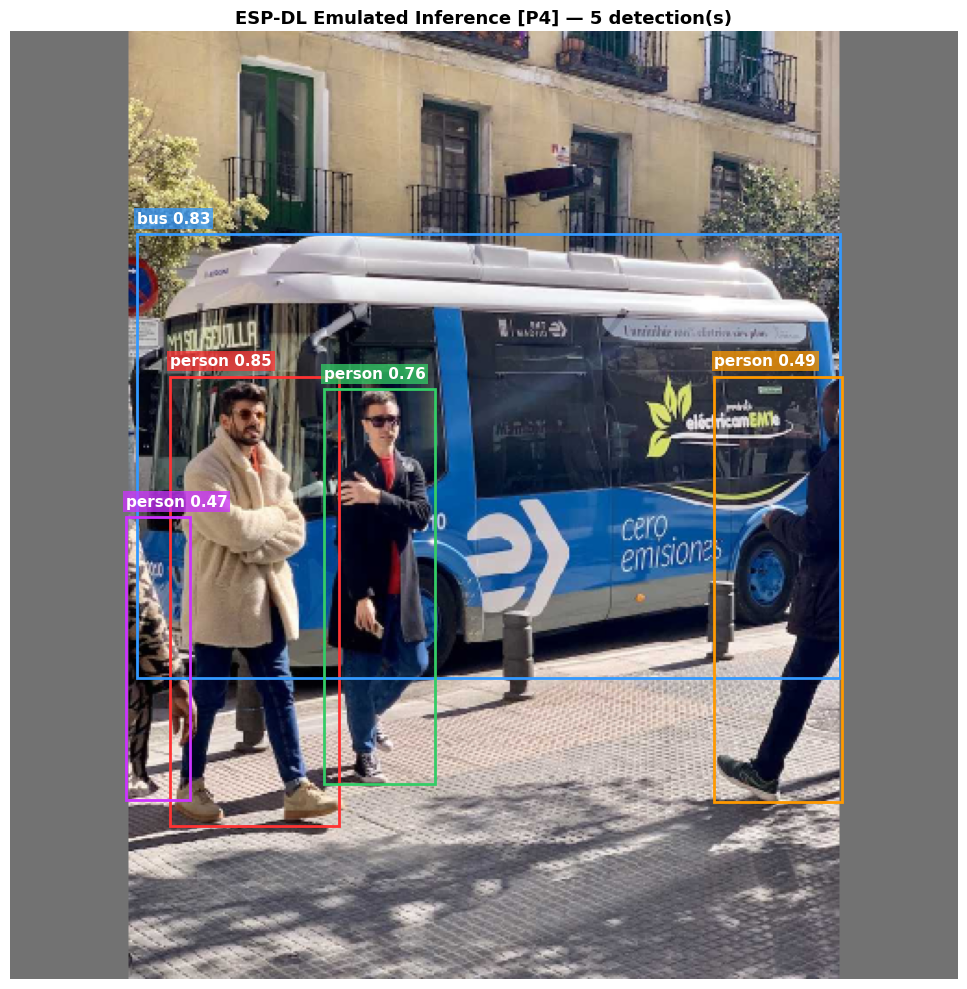


Detections (5):
  [  0] person                conf=0.85  box=[86, 186, 177, 429]
  [  5] bus                   conf=0.83  box=[68, 109, 448, 349]
  [  0] person                conf=0.76  box=[169, 193, 229, 406]
  [  0] person                conf=0.49  box=[380, 186, 449, 416]
  [  0] person                conf=0.47  box=[62, 262, 97, 415]


In [12]:
# ==========================================
# CELL 12: Inference Preview (ESP-DL Emulated)
# ==========================================
# Runs the quantized graph on a test image using SIMULATION mode + FP64
# Conv handlers to match the ESP32-P4 hardware accumulation. The half-resize
# replicates the firmware's input pipeline. Image saved as PNG (lossless)
# to avoid JPEG compression artifacts.
%matplotlib inline
from notebook_helpers import eval_espdl_model
import cv2

TEST_IMAGE = os.path.join(QATConfig.BASE_DIR, "results", "bus.jpg")
OUTPUT_DIR = os.path.join(QATConfig.BASE_DIR, "results")

# Half-resize to match firmware input pipeline
im_full = cv2.imread(TEST_IMAGE)
h, w = im_full.shape[:2]
im_half = cv2.resize(im_full, (w // 2, h // 2), interpolation=cv2.INTER_AREA)
cv2.imwrite(os.path.join(OUTPUT_DIR, "bus_s.png"), im_half)
TEST_IMAGE = os.path.join(OUTPUT_DIR, "bus_s.png")

predictions, saved_path = eval_espdl_model(
    test_image_path = TEST_IMAGE,
    graph           = graph,
    target_img_sz   = QATConfig.IMG_SZ,
    data_yaml       = QATConfig.DATA_YAML_FILE,
    platform        = PLATFORM,
    conf_thresh     = 0.25,
    output_dir      = OUTPUT_DIR,
)

print(f"\nDetections ({len(predictions)}):") 
for p in predictions:
    print(f"  [{p['class_id']:3d}] {p['class']:20s}  conf={p['score']:.2f}  box={p['box']}")

In [13]:
# ==========================================
# CELL 13: Final Export
# ==========================================
final_espdl_path = os.path.join(QATConfig.ESPDL_OUTPUT_DIR, f"yolo26n_{QATConfig.IMG_SZ}_s8_{PLATFORM}.espdl")

exporter = PFL.Exporter(platform=QATConfig.TARGET_PLATFORM)
exporter.export(final_espdl_path, graph=graph, int16_lut_step=QATConfig.INT16_LUT_STEP)
print(f"Exported: {final_espdl_path}")

[ESPDL Exporter] Switching to IDEAL MATH for Table Generation...
[INFO][ESPDL][2026-06-08 05:50:57]:  Skip onnx::Split_262 because it's not exportable
[INFO][ESPDL][2026-06-08 05:50:57]:  Skip PPQ_Variable_18 because it's not exportable
[INFO][ESPDL][2026-06-08 05:50:57]:  Skip PPQ_Variable_6 because it's not exportable
[INFO][ESPDL][2026-06-08 05:50:57]:  Skip PPQ_Variable_13 because it's not exportable
[INFO][ESPDL][2026-06-08 05:50:57]:  Skip PPQ_Variable_14 because it's not exportable
[INFO][ESPDL][2026-06-08 05:50:57]:  Skip PPQ_Variable_11 because it's not exportable
[INFO][ESPDL][2026-06-08 05:50:57]:  Skip PPQ_Variable_16 because it's not exportable
[INFO][ESPDL][2026-06-08 05:50:57]:  Skip PPQ_Variable_1 because it's not exportable
[INFO][ESPDL][2026-06-08 05:50:57]:  Skip /model.10/m/m.0/attn/Softmax_output_0 because it's not exportable
[INFO][ESPDL][2026-06-08 05:50:57]:  Skip PPQ_Variable_0 because it's not exportable
[INFO][ESPDL][2026-06-08 05:50:57]:  Skip  because it's 